In [1]:
import os
import random

import numpy as np

import matplotlib.pyplot as plt

from PIL import Image

import pandas as pd

In [2]:
train_path = "seg_train"

test_path = "seg_test"

prediction_path = "seg_pred"

train_path = os.path.join("seg_train", "seg_train")
test_path = os.path.join("seg_test", "seg_test")
print("Prediction Folder :", prediction_path)

Prediction Folder : seg_pred


In [3]:
classes = sorted(os.listdir(train_path))

print("\nAvailable Classes")

for index, class_name in enumerate(classes):

    print(f"{index+1}. {class_name}")


Available Classes
1. buildings
2. forest
3. glacier
4. mountain
5. sea
6. street


In [4]:
print()

print("Total Classes :", len(classes))


Total Classes : 6


In [5]:
image_count = {}

for class_name in classes:

    folder = os.path.join(train_path, class_name)

    total_images = len(os.listdir(folder))

    image_count[class_name] = total_images

print()

print(pd.DataFrame(

    image_count.items(),

    columns=["Class","Images"]

))



       Class  Images
0  buildings    2191
1     forest    2271
2    glacier    2404
3   mountain    2512
4        sea    2274
5     street    2382


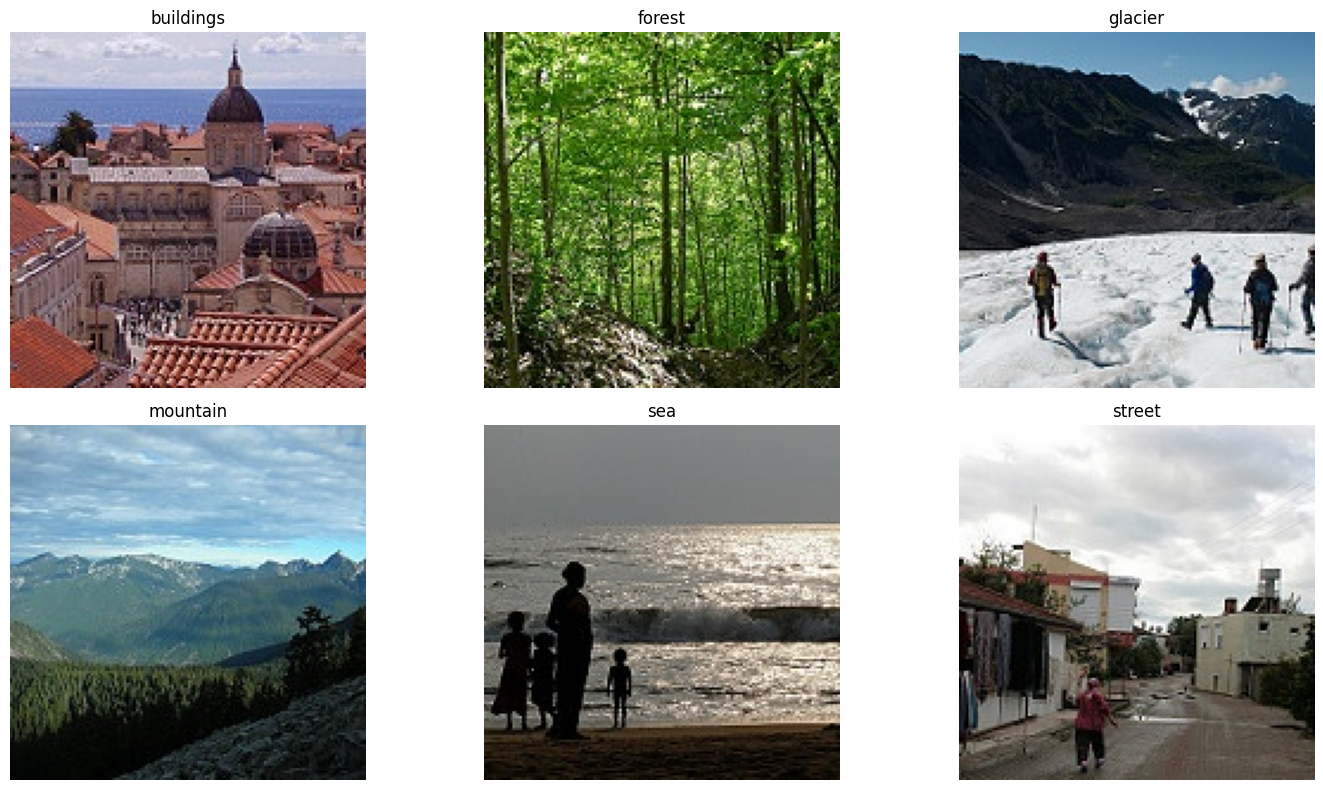

In [6]:
plt.figure(figsize=(15, 8))

for index, class_name in enumerate(classes):
    folder = os.path.join(train_path, class_name)
    
    # Filter only image files (e.g., .jpg, .png, .jpeg)
    valid_images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if not valid_images:
        continue

    image_name = random.choice(valid_images)
    image_path = os.path.join(folder, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 3, index + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

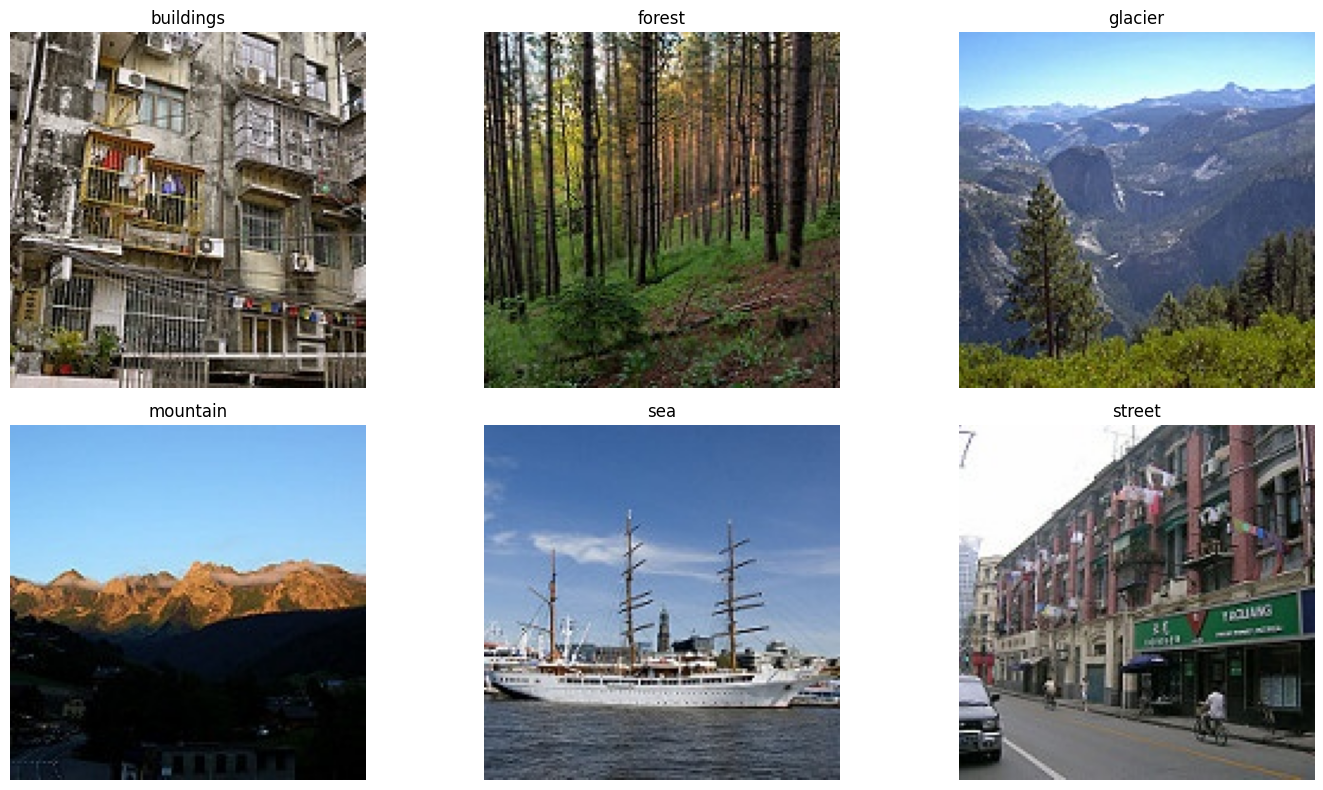

In [7]:
plt.figure(figsize=(15,8))

for index, class_name in enumerate(classes):

    folder = os.path.join(train_path, class_name)

    image_name = random.choice(

        os.listdir(folder)

    )

    image_path = os.path.join(

        folder,

        image_name

    )

    image = Image.open(image_path)

    plt.subplot(2,3,index+1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()

plt.show()


In [8]:
print()

print("Image Dimensions")

for class_name in classes:

    folder = os.path.join(train_path,class_name)

    image_name = random.choice(

        os.listdir(folder)

    )

    image_path = os.path.join(

        folder,

        image_name

    )

    image = Image.open(image_path)

    print(

        class_name,

        ":",

        image.size

    )



Image Dimensions
buildings : (150, 150)
forest : (150, 150)
glacier : (150, 150)
mountain : (150, 150)
sea : (150, 150)
street : (150, 150)


In [9]:
sample_class = classes[0]

sample_folder = os.path.join(

    train_path,

    sample_class

)

sample_image = random.choice(

    os.listdir(sample_folder)

)

sample_path = os.path.join(

    sample_folder,

    sample_image

)

image = Image.open(sample_path)

image_array = np.array(image)

print()

print("Minimum Pixel :", image_array.min())

print("Maximum Pixel :", image_array.max())

print("Image Shape :", image_array.shape)



Minimum Pixel : 0
Maximum Pixel : 251
Image Shape : (150, 150, 3)


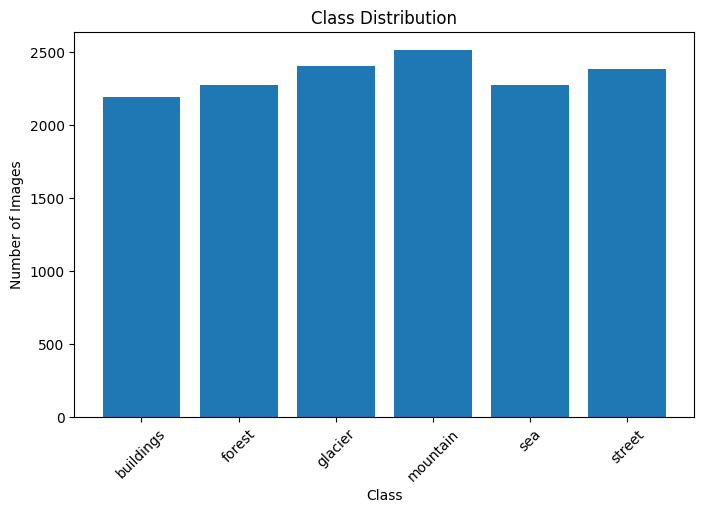

In [10]:
plt.figure(figsize=(8,5))

plt.bar(

    image_count.keys(),

    image_count.values()

)

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()


In [11]:
print()

print("======================================")

print("DATASET SUMMARY")

print("======================================")

print("Dataset Name : Intel Image Classification")

print("Framework : PyTorch")

print("Total Classes :", len(classes))

print("Classes")

for class_name in classes:

    print("-", class_name)

print()

print("Training Images")

print(sum(image_count.values()))

print()

print("Dataset Ready For Preprocessing")

print()



DATASET SUMMARY
Dataset Name : Intel Image Classification
Framework : PyTorch
Total Classes : 6
Classes
- buildings
- forest
- glacier
- mountain
- sea
- street

Training Images
14034

Dataset Ready For Preprocessing



In [12]:

import torch

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

In [13]:
train_transform = transforms.Compose([

    transforms.Resize((150,150)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])


test_transform = transforms.Compose([

    transforms.Resize((150,150)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])


print("Image Transformations Created Successfully")


Image Transformations Created Successfully


In [14]:
train_dataset = datasets.ImageFolder(

    root=train_path,

    transform=train_transform

)

test_dataset = datasets.ImageFolder(

    root=test_path,

    transform=test_transform

)


print()

print("Training Images :", len(train_dataset))

print("Testing Images :", len(test_dataset))



Training Images : 14034
Testing Images : 3000


In [15]:
print()

print("Class Mapping")

print(train_dataset.class_to_idx)


Class Mapping
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [16]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True,

    num_workers=0

)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=0

)


print()

print("Training Batches :", len(train_loader))

print("Testing Batches :", len(test_loader))



Training Batches : 439
Testing Batches : 94


In [17]:
images, labels = next(iter(train_loader))

print()

print("Image Batch Shape")

print(images.shape)

print()

print("Label Batch Shape")

print(labels.shape)



Image Batch Shape
torch.Size([32, 3, 150, 150])

Label Batch Shape
torch.Size([32])


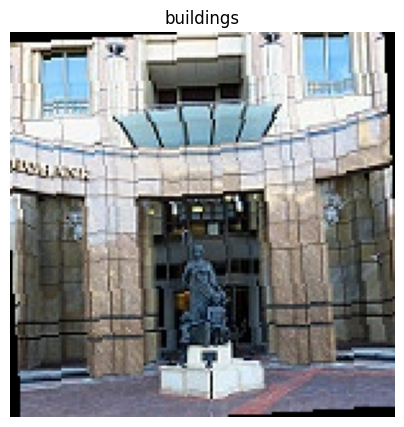

In [18]:
image = images[0]

image = image.permute(1,2,0)

image = image.numpy()

image = (image * np.array([0.229,0.224,0.225])) + np.array([0.485,0.456,0.406])

image = np.clip(image,0,1)

plt.figure(figsize=(5,5))

plt.imshow(image)

plt.title(

    classes[labels[0]]

)

plt.axis("off")

plt.show()


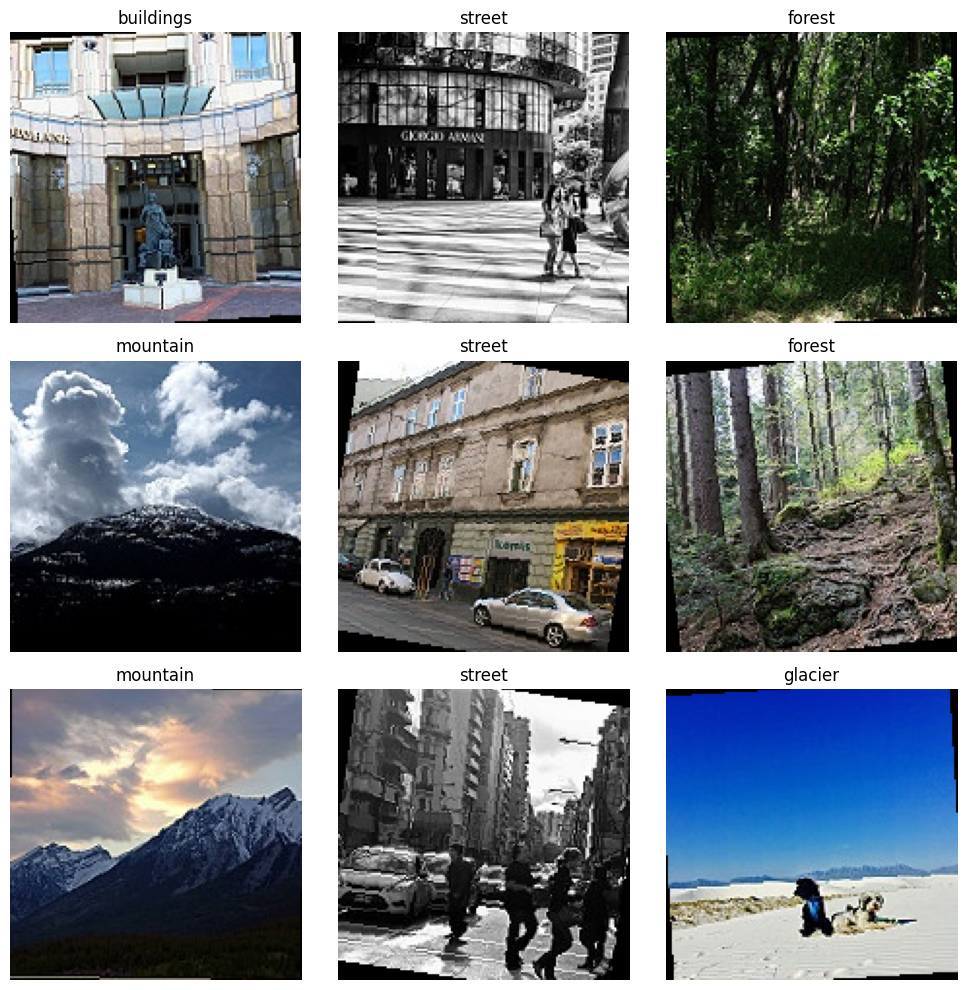

In [19]:
plt.figure(figsize=(10,10))

for i in range(9):

    image = images[i]

    image = image.permute(1,2,0)

    image = image.numpy()

    image = (image * np.array([0.229,0.224,0.225])) + np.array([0.485,0.456,0.406])

    image = np.clip(image,0,1)

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.title(classes[labels[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()


In [20]:
import joblib

joblib.dump(

    classes,

    "class_names.pkl"

)

print()

print("Class Names Saved Successfully")



Class Names Saved Successfully


In [21]:
print()

print("Image Shape :", images.shape)

print("Number of Classes :", len(classes))

print("Classes")

for c in classes:

    print("-", c)



Image Shape : torch.Size([32, 3, 150, 150])
Number of Classes : 6
Classes
- buildings
- forest
- glacier
- mountain
- sea
- street


In [22]:
device = torch.device(

    "cuda" if torch.cuda.is_available() else "cpu"

)

print()

print("Running On :", device)



Running On : cpu


In [23]:
print()

print("======================================")

print("✔ Image Transformations Applied")

print("✔ Data Augmentation Completed")

print("✔ ImageFolder Created")

print("✔ DataLoader Created")

print("✔ Batch Verification Completed")

print("✔ Class Mapping Generated")

print("✔ Class Names Saved")

print("✔ Ready For CNN Model Development")


✔ Image Transformations Applied
✔ Data Augmentation Completed
✔ ImageFolder Created
✔ DataLoader Created
✔ Batch Verification Completed
✔ Class Mapping Generated
✔ Class Names Saved
✔ Ready For CNN Model Development


In [24]:
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

In [25]:
class CNNModel(nn.Module):

    def __init__(self):

        super(CNNModel, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 18 * 18, 256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, len(classes))

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


model = CNNModel().to(device)

print(model)


CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=41472, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=6, bias=True)
  )
)


In [26]:
criterion = nn.CrossEntropyLoss()


In [27]:
optimizer = optim.Adam(

    model.parameters(),

    lr=0.001

)


In [28]:
epochs = 10

train_losses = []

train_accuracies = []

In [29]:
for epoch in range(epochs):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )


Epoch [1/10] Loss: 0.9798 Accuracy: 62.56%
Epoch [2/10] Loss: 0.6539 Accuracy: 76.26%
Epoch [3/10] Loss: 0.5687 Accuracy: 79.70%
Epoch [4/10] Loss: 0.5160 Accuracy: 81.49%
Epoch [5/10] Loss: 0.4815 Accuracy: 83.36%
Epoch [6/10] Loss: 0.4554 Accuracy: 83.55%
Epoch [7/10] Loss: 0.4111 Accuracy: 85.08%
Epoch [8/10] Loss: 0.3907 Accuracy: 86.10%
Epoch [9/10] Loss: 0.3734 Accuracy: 86.62%
Epoch [10/10] Loss: 0.3483 Accuracy: 87.49%


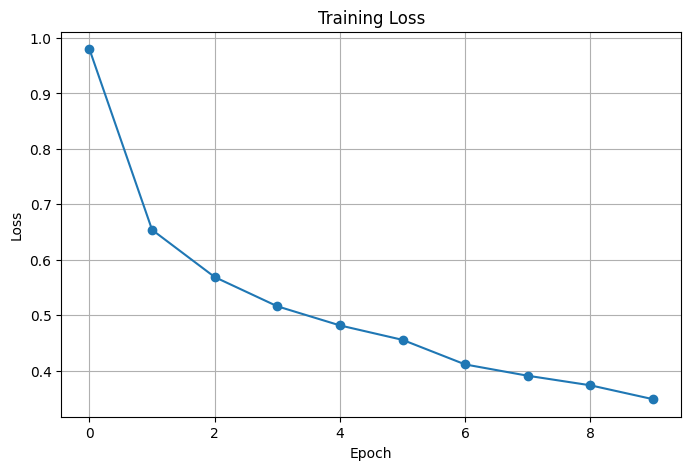

In [30]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker="o")

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()


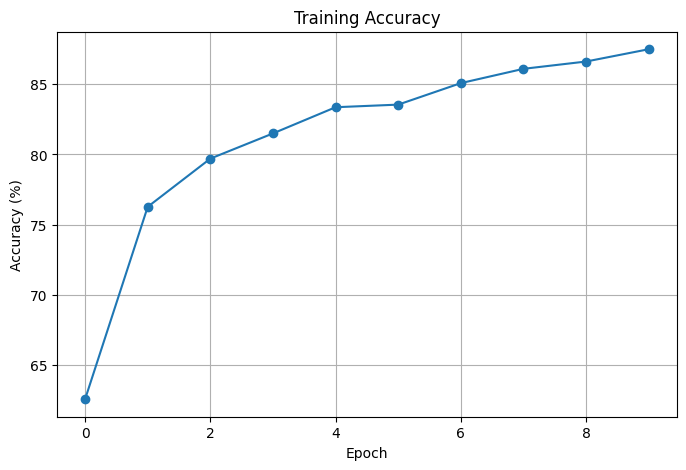

In [31]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, marker="o")

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()


In [32]:
model.eval()

all_predictions = []

all_labels = []

correct = 0

total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())


test_accuracy = 100 * correct / total

print()

print("Test Accuracy :", round(test_accuracy,2), "%")



Test Accuracy : 85.1 %


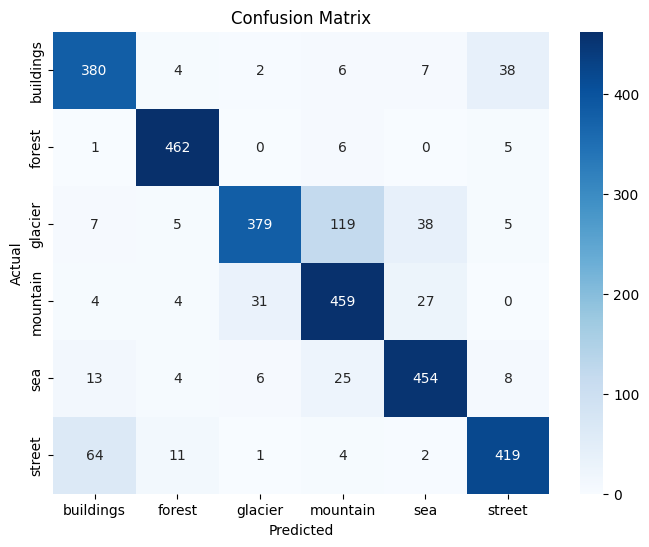

In [33]:
cm = confusion_matrix(

    all_labels,

    all_predictions

)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=classes,

    yticklabels=classes

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [34]:
print()

print(classification_report(

    all_labels,

    all_predictions,

    target_names=classes

))


              precision    recall  f1-score   support

   buildings       0.81      0.87      0.84       437
      forest       0.94      0.97      0.96       474
     glacier       0.90      0.69      0.78       553
    mountain       0.74      0.87      0.80       525
         sea       0.86      0.89      0.87       510
      street       0.88      0.84      0.86       501

    accuracy                           0.85      3000
   macro avg       0.86      0.86      0.85      3000
weighted avg       0.86      0.85      0.85      3000



In [35]:
torch.save(

    model.state_dict(),

    "cnn_model.pth"

)

print()

print("CNN Model Saved Successfully")



CNN Model Saved Successfully


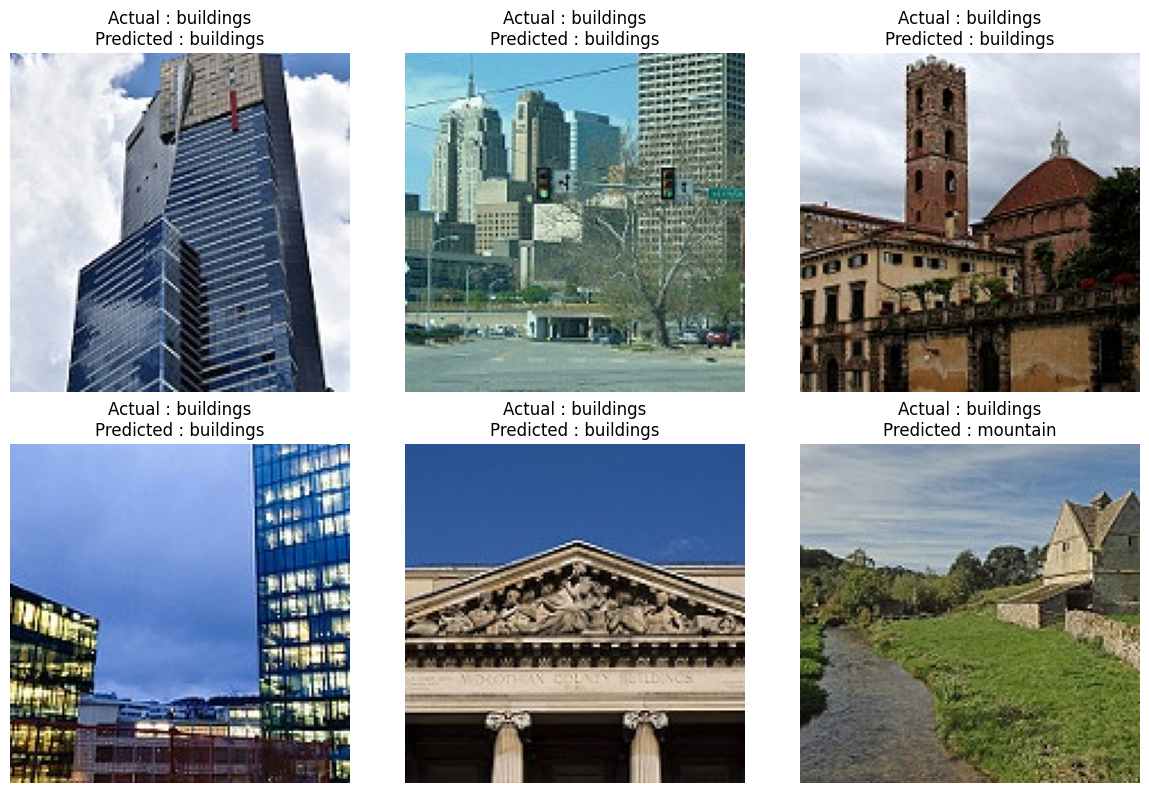

In [36]:
images, labels = next(iter(test_loader))

images = images.to(device)

model.eval()

with torch.no_grad():

    outputs = model(images)

_, predictions = torch.max(outputs,1)

plt.figure(figsize=(12,8))

for i in range(6):

    image = images[i].cpu().permute(1,2,0).numpy()

    image = (image * np.array([0.229,0.224,0.225])) + np.array([0.485,0.456,0.406])

    image = np.clip(image,0,1)

    plt.subplot(2,3,i+1)

    plt.imshow(image)

    plt.title(

        f"Actual : {classes[labels[i]]}\nPredicted : {classes[predictions[i]]}"

    )

    plt.axis("off")

plt.tight_layout()

plt.show()


In [37]:
print()


print("=======================================")

print("CNN Model Built Successfully")

print("Model Trained Successfully")

print("Training Accuracy :", round(train_accuracies[-1],2), "%")

print("Testing Accuracy :", round(test_accuracy,2), "%")

print("Confusion Matrix Generated")

print("Classification Report Generated")

print("CNN Model Saved Successfully")

print()

print("Ready For Deployment")


CNN Model Built Successfully
Model Trained Successfully
Training Accuracy : 87.49 %
Testing Accuracy : 85.1 %
Confusion Matrix Generated
Classification Report Generated
CNN Model Saved Successfully

Ready For Deployment


In [38]:
app_code = '''

from fastapi import FastAPI, File, UploadFile
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
import joblib
import numpy as np


# -------------------------------
# Load Class Names
# -------------------------------

classes = joblib.load("class_names.pkl")


# -------------------------------
# CNN MODEL
# -------------------------------

class CNNModel(nn.Module):

    def __init__(self):

        super(CNNModel,self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*18*18,256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256,len(classes))

        )

    def forward(self,x):

        return self.classifier(self.features(x))


model = CNNModel()

model.load_state_dict(

    torch.load(

        "cnn_model.pth",

        map_location=torch.device("cpu")

    )

)

model.eval()


transform = transforms.Compose([

    transforms.Resize((150,150)),

    transforms.ToTensor(),

    transforms.Normalize(

        [0.485,0.456,0.406],

        [0.229,0.224,0.225]

    )

])


app = FastAPI(

    title="CNN Image Recognition API",

    version="1.0"

)


@app.get("/")

def home():

    return {

        "message":"CNN Image Recognition API"

    }


@app.post("/predict")

async def predict(file: UploadFile = File(...)):

    image = Image.open(file.file).convert("RGB")

    image = transform(image)

    image = image.unsqueeze(0)

    with torch.no_grad():

        output = model(image)

        probability = torch.softmax(output,dim=1)

        confidence,prediction = torch.max(

            probability,

            dim=1

        )

    return {

        "Predicted_Class":classes[prediction.item()],

        "Confidence":round(float(confidence.item()),4)

    }

'''

print(app_code)




from fastapi import FastAPI, File, UploadFile
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
import joblib
import numpy as np


# -------------------------------
# Load Class Names
# -------------------------------

classes = joblib.load("class_names.pkl")


# -------------------------------
# CNN MODEL
# -------------------------------

class CNNModel(nn.Module):

    def __init__(self):

        super(CNNModel,self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*18*18,256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(

In [39]:
with open("app.py","w") as file:

    file.write(app_code)

print("app.py Created Successfully")

app.py Created Successfully


In [40]:
requirements = '''

torch
torchvision
numpy
pandas
matplotlib
Pillow
joblib
fastapi
uvicorn
python-multipart

'''

with open("requirements.txt","w") as file:

    file.write(requirements)

print("requirements.txt Created Successfully")

requirements.txt Created Successfully


In [41]:
print("""

Image_Recognition_CNN/

│

├── seg_train/

├── seg_test/

├── seg_pred/

├── cnn_model.pth

├── class_names.pkl

├── app.py

├── requirements.txt

└── Image_Recognition_Using_CNN.ipynb

""")





Image_Recognition_CNN/

│

├── seg_train/

├── seg_test/

├── seg_pred/

├── cnn_model.pth

├── class_names.pkl

├── app.py

├── requirements.txt

└── Image_Recognition_Using_CNN.ipynb




In [42]:
print("""

Open Terminal

Run:

uvicorn app:app --reload

""")




Open Terminal

Run:

uvicorn app:app --reload




In [43]:
print("""

Open Browser

http://127.0.0.1:8000/docs

""")




Open Browser

http://127.0.0.1:8000/docs




In [44]:
print("""

1. Click POST /predict

2. Click Try it out

3. Upload any JPG or PNG image

4. Click Execute

""")



1. Click POST /predict

2. Click Try it out

3. Upload any JPG or PNG image

4. Click Execute




In [45]:
print("""

{

    "Predicted_Class":"forest",

    "Confidence":0.9876

}

""")




{

    "Predicted_Class":"forest",

    "Confidence":0.9876

}




In [46]:
print("""

Future Improvements

✔ Transfer Learning (ResNet18)

✔ ResNet50

✔ EfficientNet

✔ MobileNetV3

✔ Vision Transformer (ViT)

✔ Grad-CAM Visualization

✔ TensorBoard Logging

✔ Docker Deployment

✔ AWS EC2 Deployment

✔ Streamlit Frontend

✔ ONNX Model Export

✔ Quantization for Faster CPU Inference

""")



Future Improvements

✔ Transfer Learning (ResNet18)

✔ ResNet50

✔ EfficientNet

✔ MobileNetV3

✔ Vision Transformer (ViT)

✔ Grad-CAM Visualization

✔ TensorBoard Logging

✔ Docker Deployment

✔ AWS EC2 Deployment

✔ Streamlit Frontend

✔ ONNX Model Export

✔ Quantization for Faster CPU Inference




In [47]:
print()

print("===================================================")

print("END-TO-END CNN PROJECT COMPLETED SUCCESSFULLY")

print("===================================================")

print("✔ Data Understanding & EDA")

print("✔ Image Preprocessing")

print("✔ Data Augmentation")

print("✔ DataLoader")

print("✔ CNN Model Development")

print("✔ Model Training")

print("✔ Model Evaluation")

print("✔ Confusion Matrix")

print("✔ Classification Report")

print("✔ Model Saved (.pth)")

print("✔ FastAPI Deployment")

print("✔ Swagger API")

print("✔ Image Prediction API")

print()

print("Congratulations!")

print("You have successfully built an End-to-End")

print("Image Recognition System using CNN and PyTorch.")


END-TO-END CNN PROJECT COMPLETED SUCCESSFULLY
✔ Data Understanding & EDA
✔ Image Preprocessing
✔ Data Augmentation
✔ DataLoader
✔ CNN Model Development
✔ Model Training
✔ Model Evaluation
✔ Confusion Matrix
✔ Classification Report
✔ Model Saved (.pth)
✔ FastAPI Deployment
✔ Swagger API
✔ Image Prediction API

Congratulations!
You have successfully built an End-to-End
Image Recognition System using CNN and PyTorch.
